# 03B - Commerce Multi-Class Risk Model

This notebook develops the **Commerce Academic Risk Model** for the Smart Learning System.

It follows the outputs generated by:

- `01_Data_Understanding_EDA.ipynb`
- `02_Data_Preprocessing.ipynb`

The model predicts student academic risk level using Sri Lankan A/L Commerce-aligned features:

- Accounting score
- Business Studies score
- Economics score
- Attendance percentage

## 1. Notebook Objectives

This notebook includes all steps required for the Commerce risk-model development stage:

- Load the processed Commerce risk dataset from Notebook 02
- Validate feature and target columns
- Check class distribution and imbalance
- Separate features and target
- Exclude leakage-prone columns such as `Subject_Average`
- Split the dataset into training and testing sets
- Train Logistic Regression, Decision Tree, and Random Forest models
- Use leakage-safe pipelines
- Evaluate using accuracy, balanced accuracy, macro precision, macro recall, macro F1-score, and cross-validation metrics
- Save comparison reports, classification reports, confusion matrices, and feature-importance outputs

Final `.pkl` export is intentionally left for the final evaluation/export notebook after tuning.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 2. Resolve Project Paths

The notebook can be executed from the project root or from the `ml-model/notebooks` directory.

In [2]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    ML_ROOT = NOTEBOOK_DIR.parent
elif NOTEBOOK_DIR.name == "ml-model":
    ML_ROOT = NOTEBOOK_DIR
else:
    ML_ROOT = NOTEBOOK_DIR / "ml-model"

PROCESSED_DATA_DIR = ML_ROOT / "datasets" / "processed"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"
MODELS_DIR = ML_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

COMMERCE_RISK_DATASET = PROCESSED_DATA_DIR / "commerce_risk_dataset.csv"
METADATA_PATH = PROCESSED_DATA_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT.resolve())
print("Commerce risk dataset:", COMMERCE_RISK_DATASET.resolve())
print("Reports directory:", REPORTS_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Commerce risk dataset: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/commerce_risk_dataset.csv
Reports directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Load Preprocessing Metadata

Notebook 02 exported preprocessing metadata. This notebook also defines Commerce-specific features because the final Commerce dataset uses domain-specific column names.

In [3]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata file not found: {METADATA_PATH.resolve()}")

metadata = json.loads(METADATA_PATH.read_text())

commerce_risk_features = [
    "Accounting_Score",
    "Business_Studies_Score",
    "Economics_Score",
    "Attendance_Percentage",
]
commerce_risk_target = "risk_level"

print("Commerce risk features:", commerce_risk_features)
print("Commerce risk target:", commerce_risk_target)
print("Data leakage note:", metadata.get("data_leakage_prevention"))

Commerce risk features: ['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']
Commerce risk target: risk_level
Data leakage note: Scaling, fitted imputation, encoding objects and resampling are fitted only on the training split during model training.


## 4. Data Leakage Prevention

This notebook prevents leakage in three ways:

1. `Subject_Average` is excluded because it was used to derive risk labels.
2. Median imputation and scaling are fitted only inside training pipelines.
3. Cross-validation evaluates the complete pipeline inside each fold.

No scaling, fitted imputation, or resampling is applied to the full dataset before train/test splitting.

## 5. Load Commerce Risk Dataset

The processed Commerce dataset was generated by Notebook 02. It maps the original score columns into A/L Commerce subject names.

In [4]:
if not COMMERCE_RISK_DATASET.exists():
    raise FileNotFoundError(f"Commerce risk dataset not found: {COMMERCE_RISK_DATASET.resolve()}")

commerce_df = pd.read_csv(COMMERCE_RISK_DATASET)

print("Dataset shape:", commerce_df.shape)
display(commerce_df.head())

Dataset shape: (1002, 7)


,student_id,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage,Subject_Average,risk_level
0,COM0001,79.967142,86.792265,72.598574,75.460962,79.79,Low Risk
1,COM0002,73.617357,81.095604,76.843851,80.698075,77.19,Low Risk
2,COM0003,81.476885,70.715564,71.660641,82.931972,74.62,Low Risk
3,COM0004,90.230299,62.236759,75.536308,94.438438,76.00,Low Risk
4,COM0005,72.658466,78.378680,62.851083,87.782766,71.30,Low Risk


## 6. Validate Required Columns and Data Types

The model uses only subject scores and attendance as input features.

In [5]:
required_columns = commerce_risk_features + [commerce_risk_target]
missing_columns = [column for column in required_columns if column not in commerce_df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are available.")
display(commerce_df[required_columns].dtypes.to_frame("Data Type"))

All required columns are available.


,Data Type
Accounting_Score,float64
Business_Studies_Score,float64
Economics_Score,float64
Attendance_Percentage,float64
risk_level,str


## 7. Leakage Column Check

`Subject_Average` exists for documentation and label derivation, but it is not used as a model feature.

In [6]:
leakage_risk_columns = ["Subject_Average"]

for column in leakage_risk_columns:
    print(f"{column} present in dataset:", column in commerce_df.columns)

print("Model feature columns:", commerce_risk_features)
print("Leakage-prone columns excluded from X:", leakage_risk_columns)

Subject_Average present in dataset: True
Model feature columns: ['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']
Leakage-prone columns excluded from X: ['Subject_Average']


## 8. Target Distribution and Class Imbalance

The expected conceptual classes are:

- High Risk
- Medium Risk
- Low Risk

However, the current processed dataset may not contain all three classes. The notebook dynamically trains on the available classes and documents this limitation.

In [7]:
def class_distribution(df, target):
    target_counts = df[target].value_counts(dropna=False)
    target_percentages = df[target].value_counts(normalize=True, dropna=False) * 100

    return pd.DataFrame({
        "Count": target_counts,
        "Percentage": target_percentages.round(2),
    })

commerce_class_summary = class_distribution(commerce_df, commerce_risk_target)
display(commerce_class_summary)

expected_classes = ["High Risk", "Medium Risk", "Low Risk"]
available_classes = [label for label in expected_classes if label in set(commerce_df[commerce_risk_target])]
missing_expected_classes = [label for label in expected_classes if label not in set(commerce_df[commerce_risk_target])]

print("Available classes:", available_classes)
print("Missing expected classes:", missing_expected_classes or "None")

class_balance_path = REPORTS_DIR / "commerce_risk_class_balance_summary.csv"
commerce_class_summary.to_csv(class_balance_path)
print("Saved:", class_balance_path.resolve())

,Count,Percentage
risk_level,,
Low Risk,974,97.21
Medium Risk,28,2.79


Available classes: ['Medium Risk', 'Low Risk']
Missing expected classes: ['High Risk']
Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_class_balance_summary.csv


## 9. Feature and Target Separation

The feature matrix uses only Commerce subjects and attendance.

In [8]:
X = commerce_df[commerce_risk_features]
y = commerce_df[commerce_risk_target]

print("Feature columns:", commerce_risk_features)
print("Target column:", commerce_risk_target)
print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Feature columns: ['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']
Target column: risk_level
X shape: (1002, 4)
y shape: (1002,)


,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage
0,79.967142,86.792265,72.598574,75.460962
1,73.617357,81.095604,76.843851,80.698075
2,81.476885,70.715564,71.660641,82.931972
3,90.230299,62.236759,75.536308,94.438438
4,72.658466,78.378680,62.851083,87.782766


## 10. Train/Test Split

A stratified split is used when every class has enough samples. This preserves class balance in the training and testing sets.

In [9]:
min_class_count = int(y.value_counts().min())
stratify_target = y if min_class_count >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=stratify_target,
)

split_summary = pd.DataFrame([
    {"Split": "Training", "Rows": len(X_train), **y_train.value_counts().to_dict()},
    {"Split": "Testing", "Rows": len(X_test), **y_test.value_counts().to_dict()},
])

display(split_summary.fillna(0))

,Split,Rows,Low Risk,Medium Risk
0,Training,801,779,22
1,Testing,201,195,6


## 11. Define Candidate Models

Because this is a risk classification problem with imbalance, `class_weight="balanced"` is used where supported.

In [10]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=5,
        )),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]),
}

list(models.keys())

['Logistic Regression', 'Decision Tree', 'Random Forest']

## 12. Train Models and Evaluate on Test Set

For multi-class or imbalanced risk prediction, macro-averaged precision, recall and F1-score are more informative than accuracy alone.

In [11]:
def evaluate_multiclass_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return y_pred, {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro F1 Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Weighted F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

trained_models = {}
predictions = {}
comparison_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred, metrics = evaluate_multiclass_model(model, X_test, y_test)

    trained_models[model_name] = model
    predictions[model_name] = y_pred
    comparison_rows.append({"Model": model_name, **metrics})

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(4))

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,0.9652,0.9821,0.7308,0.9821,0.8067,0.9713
1,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
2,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


## 13. Cross-Validation Evaluation

Cross-validation is performed with stratified folds. The number of folds is capped by the smallest class count.

In [12]:
cv_splits = min(5, int(y.value_counts().min()))

cv_rows = []

if cv_splits >= 2:
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=RANDOM_STATE)

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
        "weighted_f1": "f1_weighted",
    }

    for model_name, model in models.items():
        cv_scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

        cv_rows.append({
            "Model": model_name,
            "CV Accuracy": cv_scores["test_accuracy"].mean(),
            "CV Balanced Accuracy": cv_scores["test_balanced_accuracy"].mean(),
            "CV Macro F1 Score": cv_scores["test_macro_f1"].mean(),
            "CV Weighted F1 Score": cv_scores["test_weighted_f1"].mean(),
            "CV Folds": cv_splits,
        })
else:
    for model_name in models:
        cv_rows.append({
            "Model": model_name,
            "CV Accuracy": np.nan,
            "CV Balanced Accuracy": np.nan,
            "CV Macro F1 Score": np.nan,
            "CV Weighted F1 Score": np.nan,
            "CV Folds": 0,
        })

cv_df = pd.DataFrame(cv_rows)
display(cv_df.round(4))

,Model,CV Accuracy,CV Balanced Accuracy,CV Macro F1 Score,CV Weighted F1 Score,CV Folds
0,Logistic Regression,0.9681,0.9836,0.8193,0.9741,5
1,Decision Tree,0.9990,0.9833,0.9907,0.9990,5
2,Random Forest,0.9990,0.9833,0.9907,0.9990,5


## 14. Combined Model Comparison

The best model is selected using macro F1-score and balanced accuracy, with cross-validation metrics prioritised where available.

In [13]:
full_comparison_df = comparison_df.merge(cv_df, on="Model")
full_comparison_df = full_comparison_df.sort_values(
    ["CV Macro F1 Score", "CV Balanced Accuracy", "Macro F1 Score", "Balanced Accuracy"],
    ascending=False,
).reset_index(drop=True)

display(full_comparison_df.round(4))

comparison_path = REPORTS_DIR / "commerce_risk_model_comparison.csv"
full_comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path.resolve())

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score,CV Accuracy,CV Balanced Accuracy,CV Macro F1 Score,CV Weighted F1 Score,CV Folds
0,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9990,0.9833,0.9907,0.9990,5
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9990,0.9833,0.9907,0.9990,5
2,Logistic Regression,0.9652,0.9821,0.7308,0.9821,0.8067,0.9713,0.9681,0.9836,0.8193,0.9741,5


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_model_comparison.csv


## 15. Best Model Selection

The best Commerce risk model is selected from the sorted comparison table.

In [14]:
best_model_name = full_comparison_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best Commerce Risk model:", best_model_name)
print("Selection metrics:")
display(full_comparison_df.iloc[[0]].round(4))

Best Commerce Risk model: Decision Tree
Selection metrics:


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score,CV Accuracy,CV Balanced Accuracy,CV Macro F1 Score,CV Weighted F1 Score,CV Folds
0,Decision Tree,1.0,1.0,1.0,1.0,1.0,1.0,0.999,0.9833,0.9907,0.999,5


## 16. Classification Report for Best Model

In [15]:
print(classification_report(
    y_test,
    best_predictions,
    labels=available_classes,
    zero_division=0,
))

best_report = classification_report(
    y_test,
    best_predictions,
    labels=available_classes,
    zero_division=0,
    output_dict=True,
)

best_report_path = REPORTS_DIR / "commerce_risk_best_model_classification_report.json"
best_report_path.write_text(json.dumps(best_report, indent=2))
print("Saved:", best_report_path.resolve())

              precision    recall  f1-score   support

 Medium Risk       1.00      1.00      1.00         6
    Low Risk       1.00      1.00      1.00       195

    accuracy                           1.00       201
   macro avg       1.00      1.00      1.00       201
weighted avg       1.00      1.00      1.00       201

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_best_model_classification_report.json


## 17. Confusion Matrix for Best Model

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_best_model_confusion_matrix.png


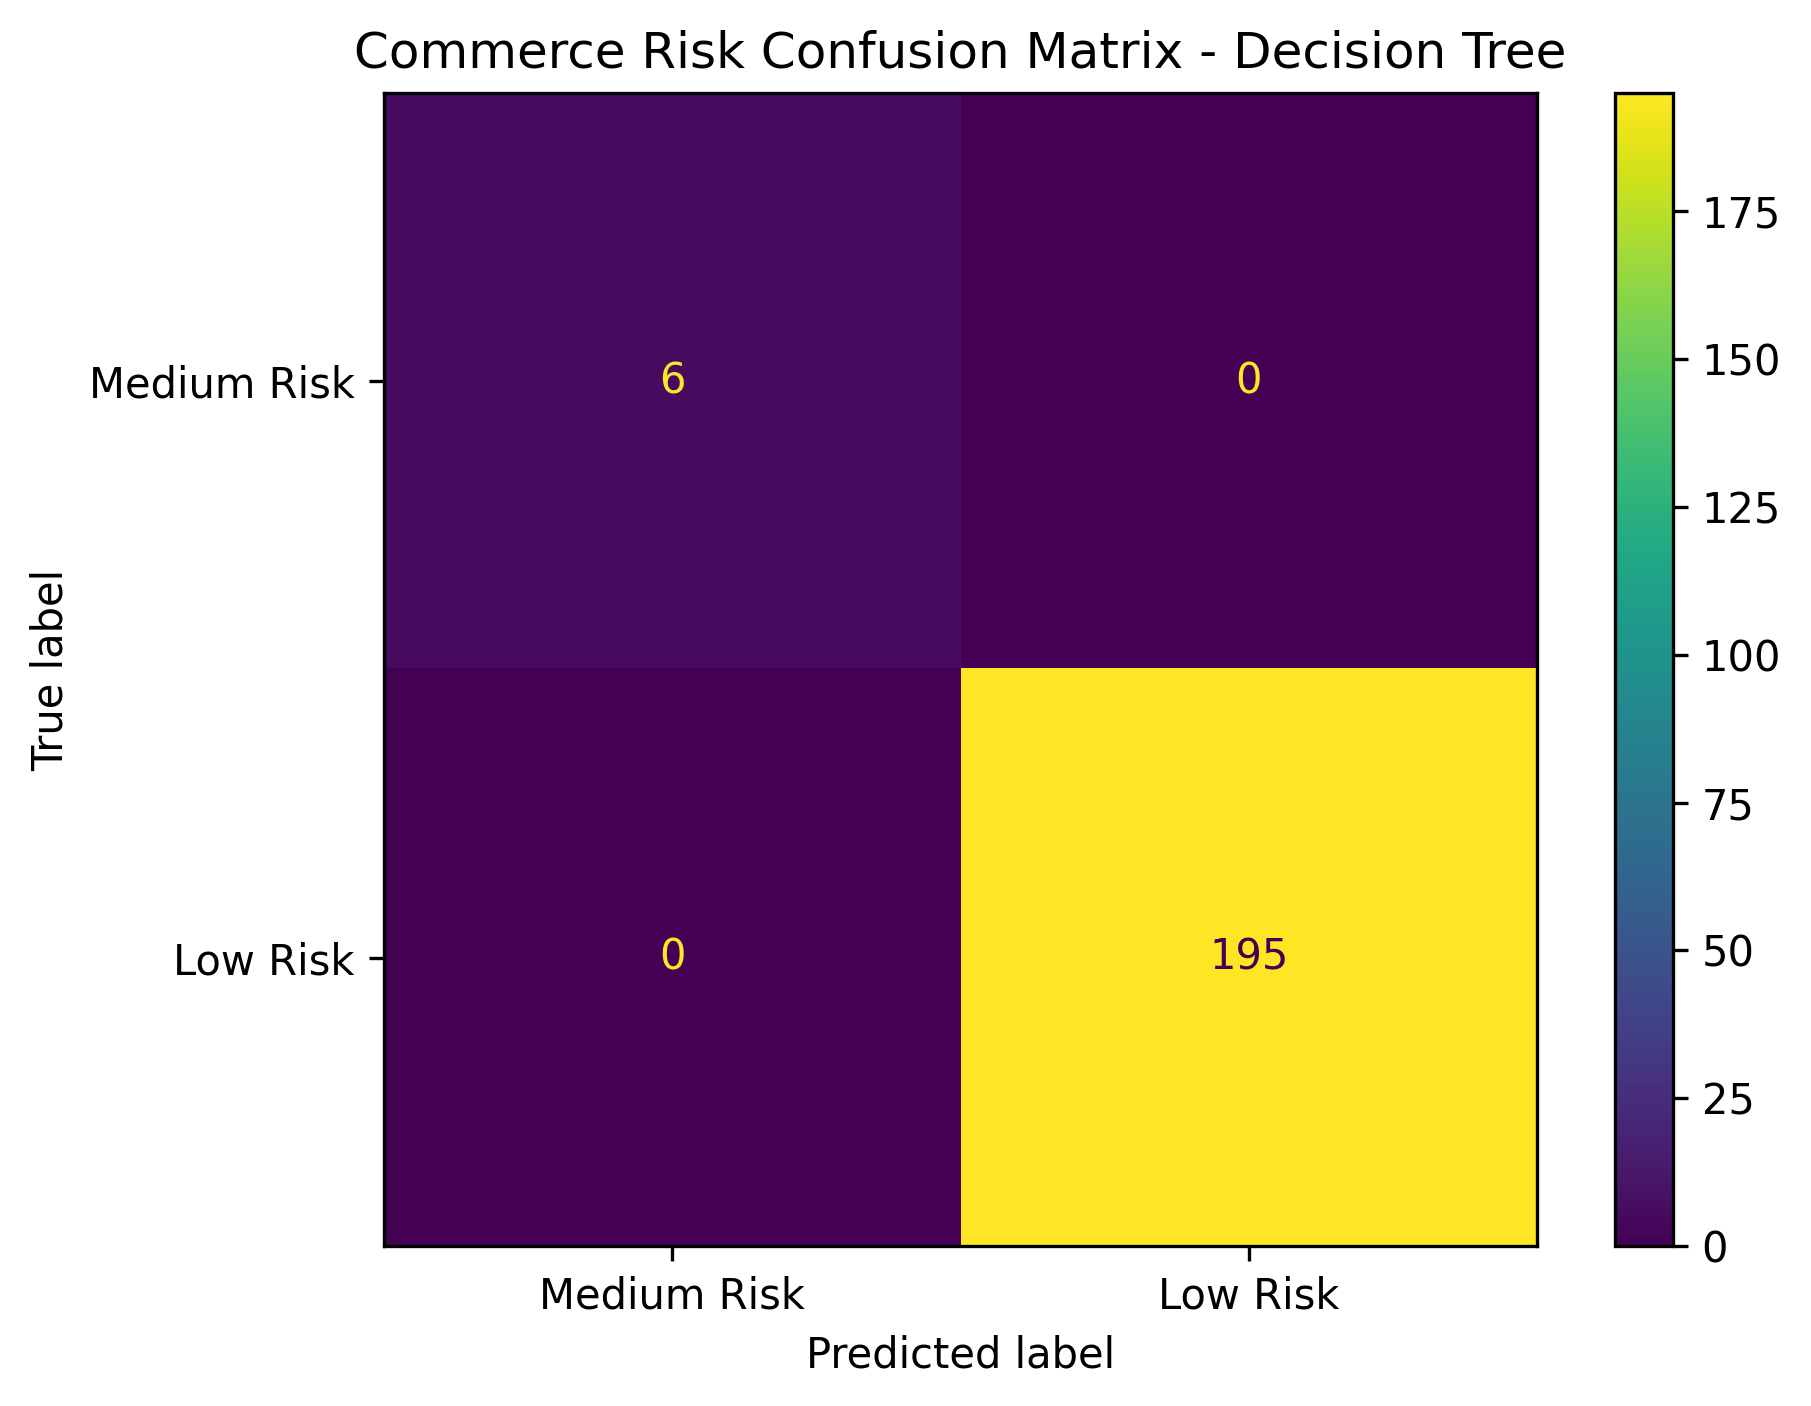

In [16]:
matrix = confusion_matrix(y_test, best_predictions, labels=available_classes)
display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=available_classes,
)

display_matrix.plot(values_format="d")
plt.title(f"Commerce Risk Confusion Matrix - {best_model_name}")
plt.tight_layout()

confusion_matrix_path = FIGURES_DIR / "commerce_risk_best_model_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=300, bbox_inches="tight")
plt.close()

print("Saved:", confusion_matrix_path.resolve())
display_image(Image(filename=str(confusion_matrix_path)))

## 18. Confusion Matrices for All Models

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_logistic_regression_confusion_matrix.png


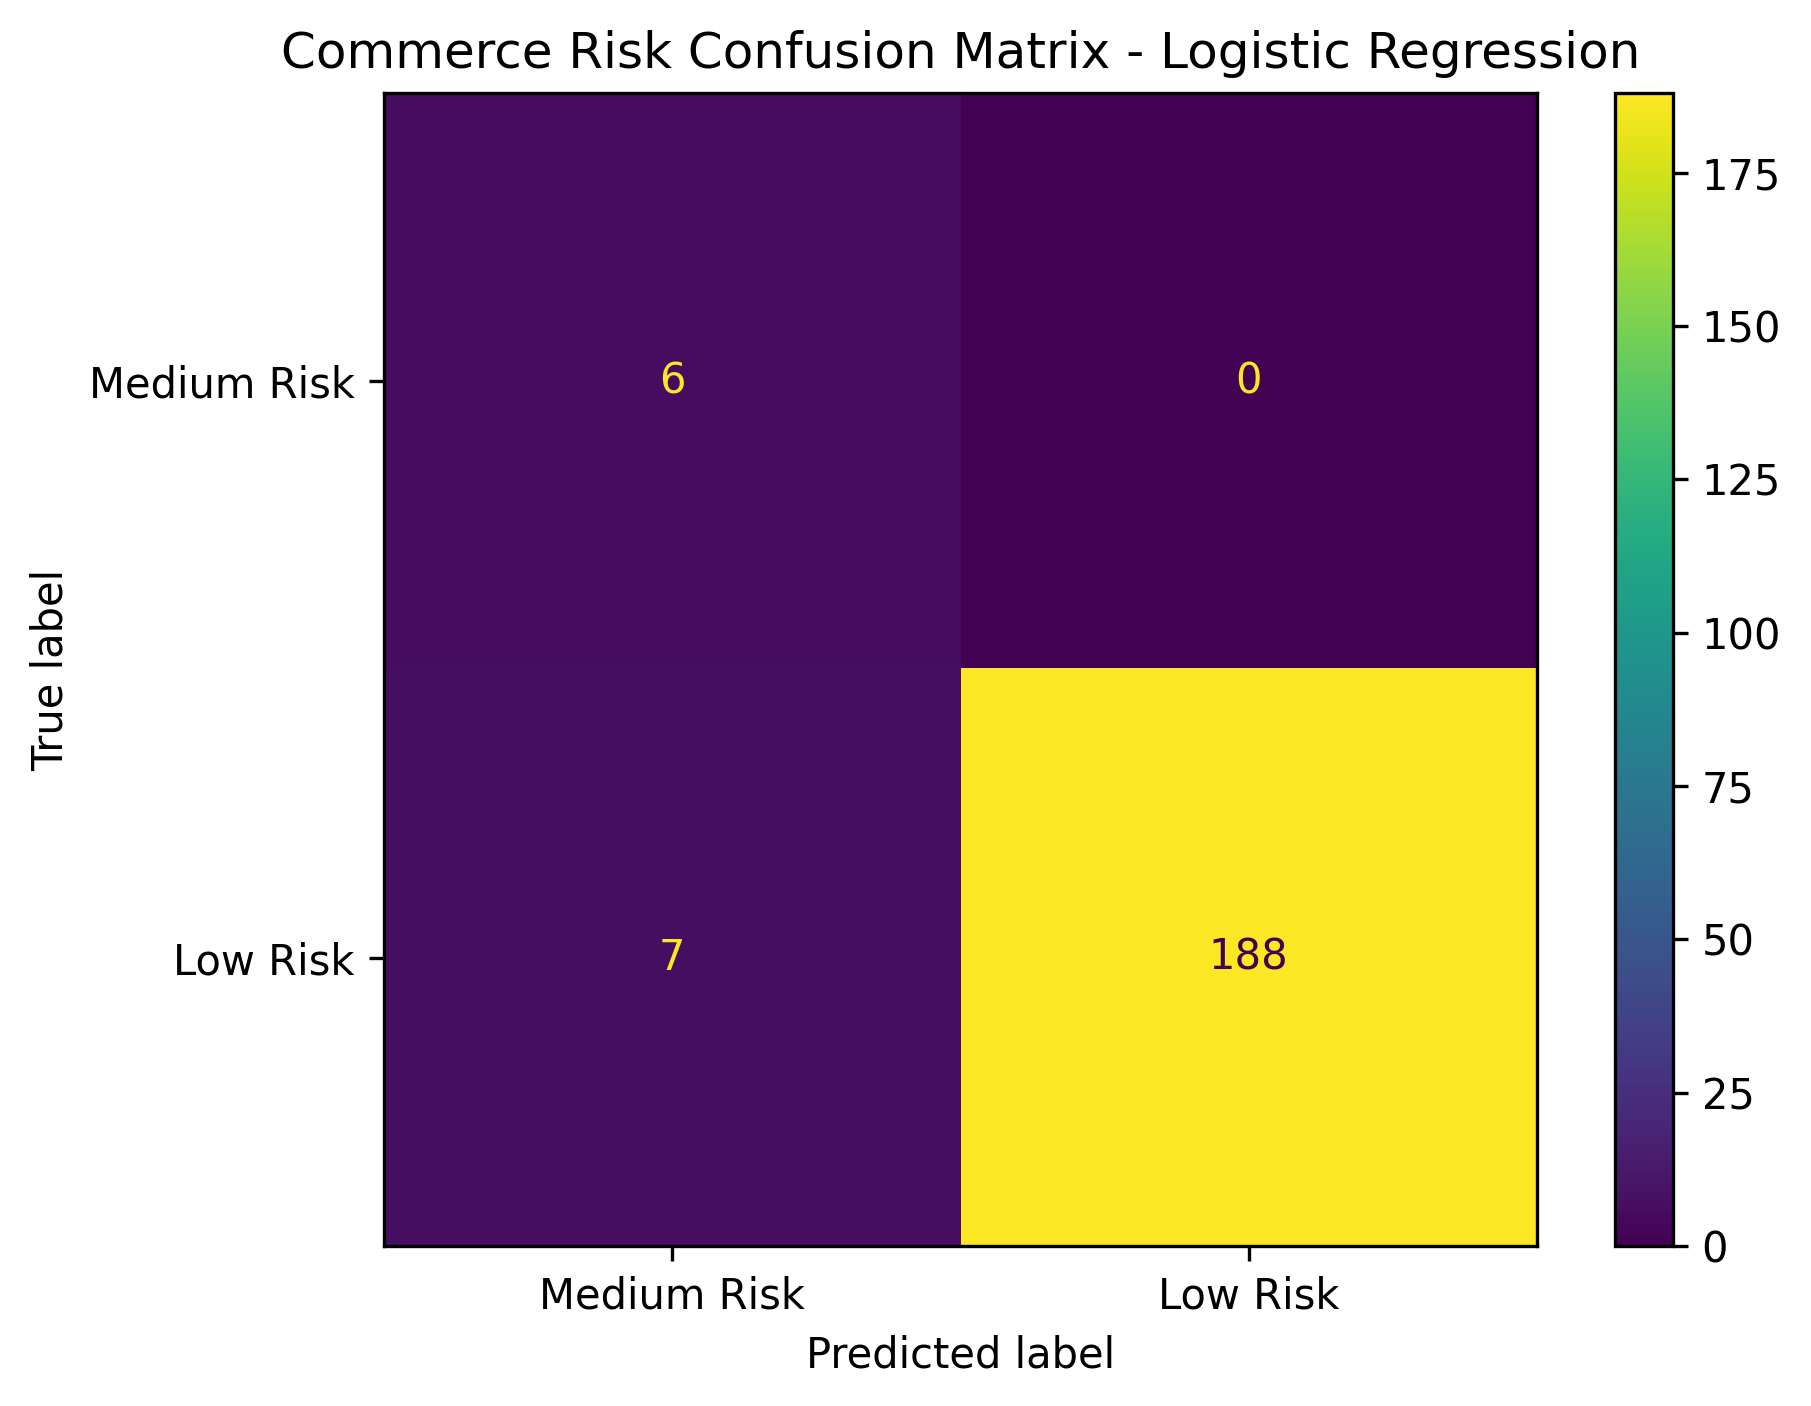

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_decision_tree_confusion_matrix.png


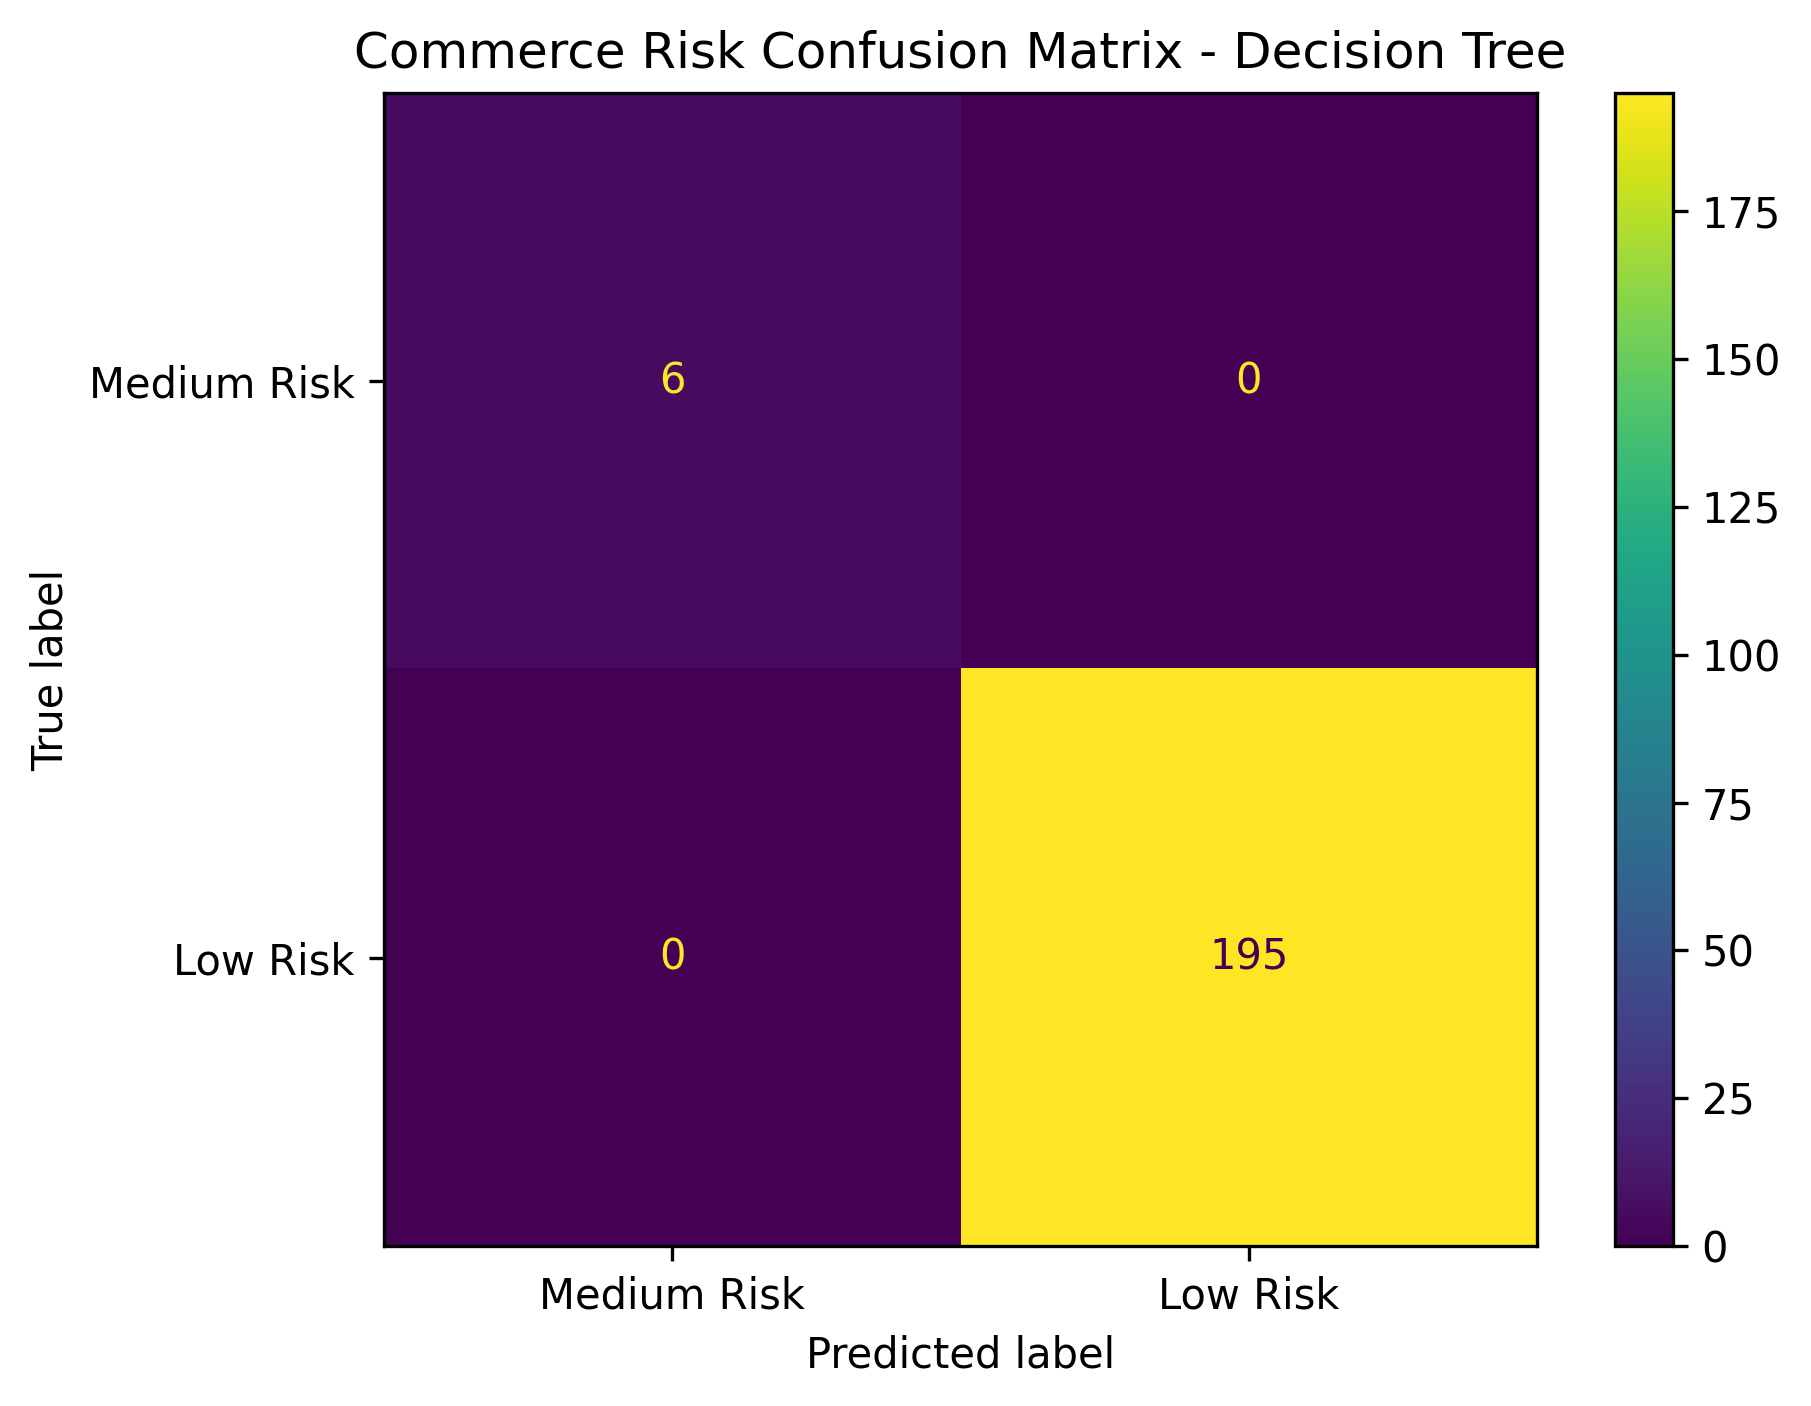

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_random_forest_confusion_matrix.png


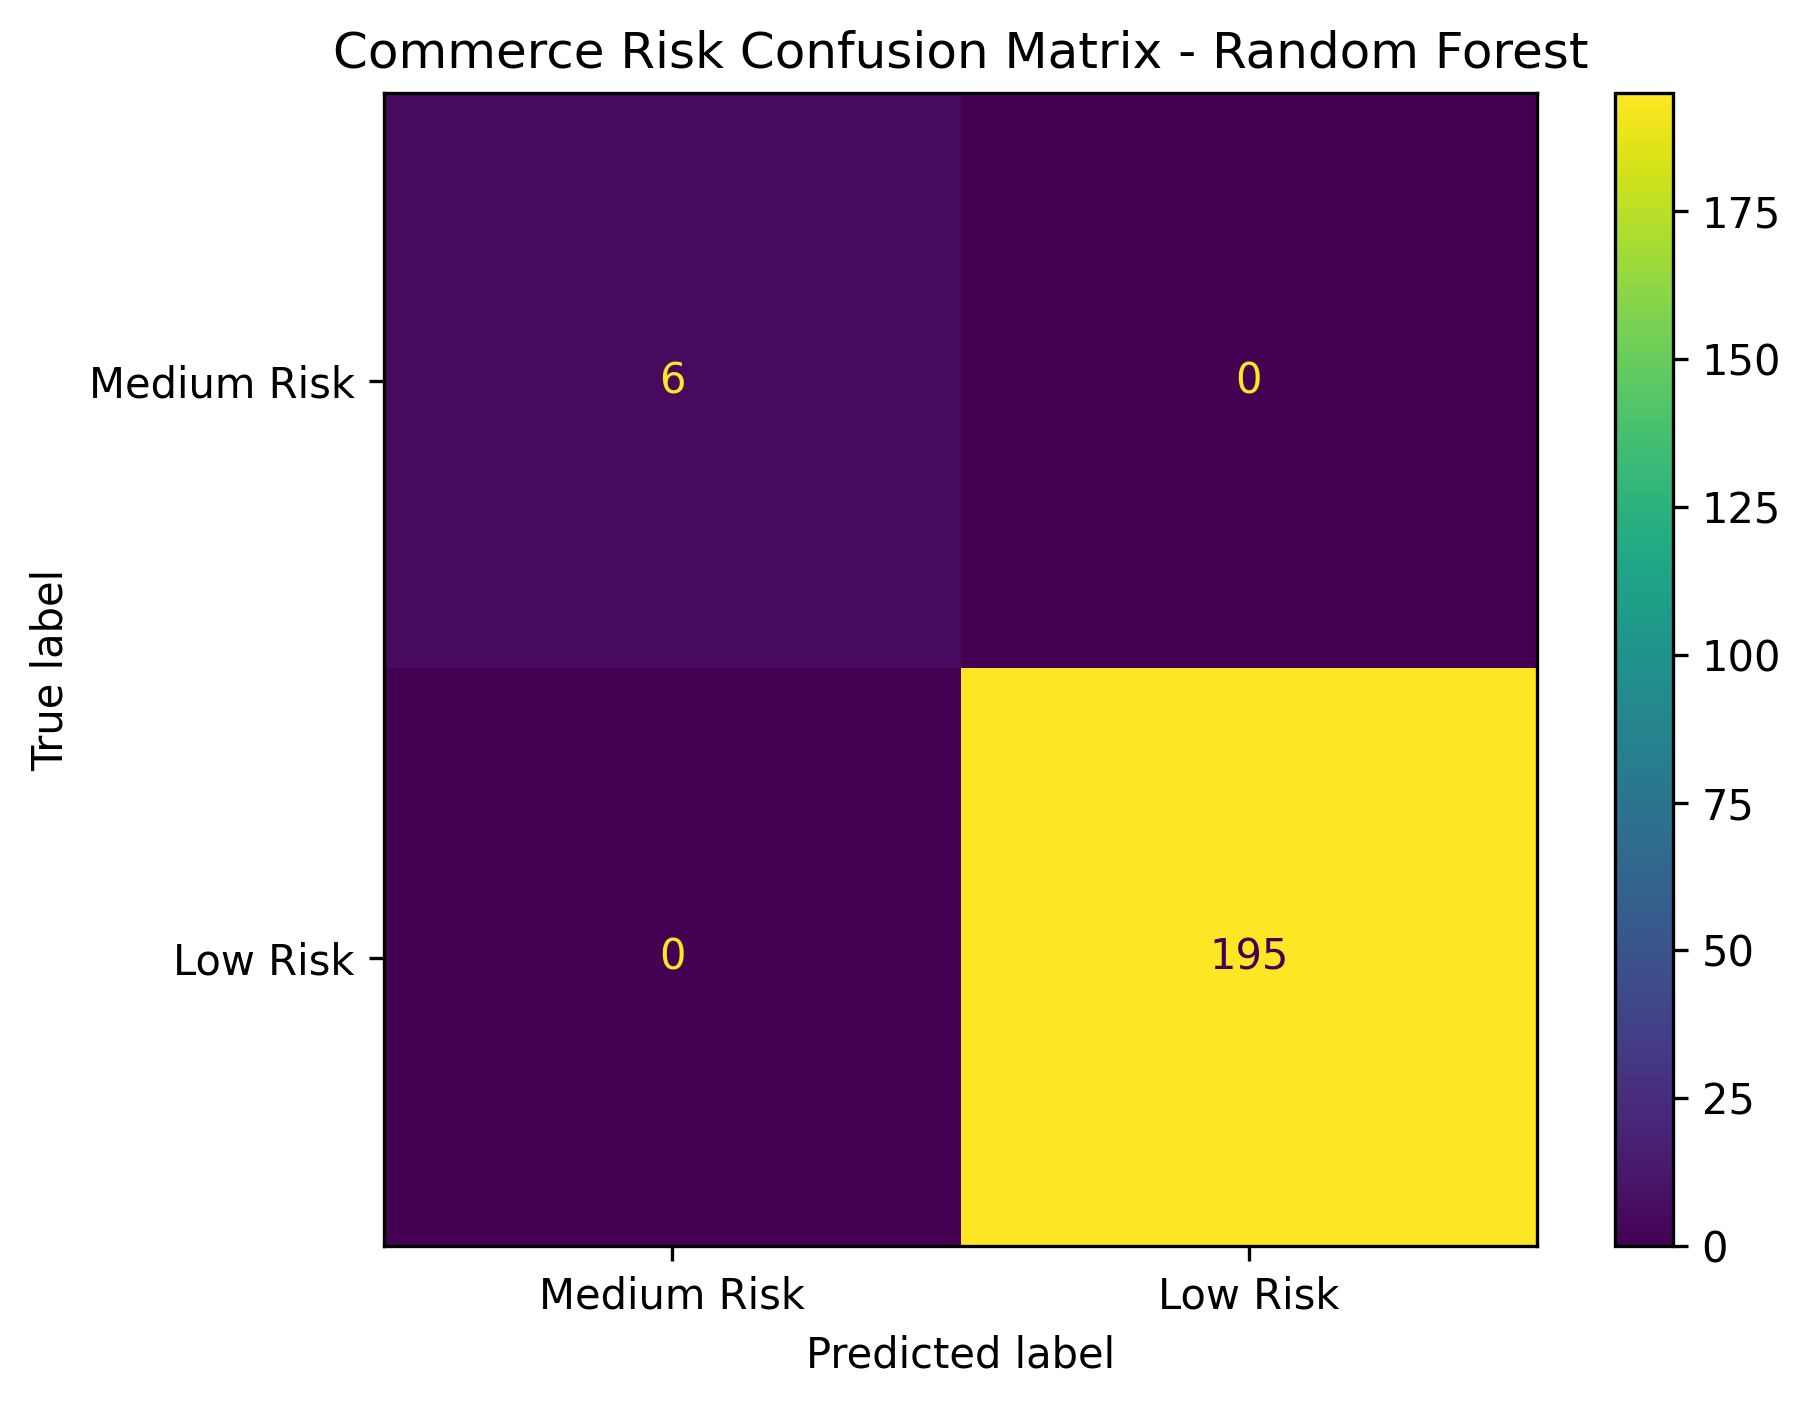

In [17]:
for model_name, y_pred in predictions.items():
    matrix = confusion_matrix(y_test, y_pred, labels=available_classes)
    display_matrix = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=available_classes,
    )

    display_matrix.plot(values_format="d")
    plt.title(f"Commerce Risk Confusion Matrix - {model_name}")
    plt.tight_layout()

    safe_name = model_name.lower().replace(" ", "_")
    output_path = FIGURES_DIR / f"commerce_risk_{safe_name}_confusion_matrix.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close()

    print("Saved:", output_path.resolve())
    display_image(Image(filename=str(output_path)))

## 19. Feature Importance / Coefficient Analysis

Tree-based models provide feature importance. Logistic Regression provides coefficients after scaling.

In [18]:
importance_rows = []

for model_name, model in trained_models.items():
    final_estimator = model.named_steps["model"]

    if hasattr(final_estimator, "feature_importances_"):
        values = final_estimator.feature_importances_
        importance_type = "feature_importance"
    elif hasattr(final_estimator, "coef_"):
        values = np.abs(final_estimator.coef_).mean(axis=0)
        importance_type = "mean_absolute_coefficient"
    else:
        continue

    for feature, value in zip(commerce_risk_features, values):
        importance_rows.append({
            "Model": model_name,
            "Importance Type": importance_type,
            "Feature": feature,
            "Value": value,
        })

importance_df = pd.DataFrame(importance_rows).sort_values(
    ["Model", "Value"],
    ascending=[True, False],
)

display(importance_df.round(4))

importance_path = REPORTS_DIR / "commerce_risk_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)
print("Saved:", importance_path.resolve())

,Model,Importance Type,Feature,Value
7,Decision Tree,feature_importance,Attendance_Percentage,1.0000
4,Decision Tree,feature_importance,Accounting_Score,0.0000
5,Decision Tree,feature_importance,Business_Studies_Score,0.0000
6,Decision Tree,feature_importance,Economics_Score,0.0000
3,Logistic Regression,mean_absolute_coefficient,Attendance_Percentage,6.3281
2,Logistic Regression,mean_absolute_coefficient,Economics_Score,0.4241
0,Logistic Regression,mean_absolute_coefficient,Accounting_Score,0.0247
1,Logistic Regression,mean_absolute_coefficient,Business_Studies_Score,0.0168
11,Random Forest,feature_importance,Attendance_Percentage,0.8612
10,Random Forest,feature_importance,Economics_Score,0.0652


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_feature_importance.csv


## 20. Best Model Summary for Documentation

In [19]:
best_model_summary = {
    "task": "Commerce Academic Risk Prediction",
    "dataset": str(COMMERCE_RISK_DATASET),
    "features": commerce_risk_features,
    "target": commerce_risk_target,
    "expected_classes": expected_classes,
    "available_classes": available_classes,
    "missing_expected_classes": missing_expected_classes,
    "candidate_models": list(models.keys()),
    "best_model": best_model_name,
    "selection_criteria": [
        "CV Macro F1 Score",
        "CV Balanced Accuracy",
        "Test Macro F1 Score",
        "Test Balanced Accuracy",
    ],
    "random_state": RANDOM_STATE,
    "data_leakage_prevention": "Subject_Average excluded; imputation and scaling are fitted only inside train-only pipelines.",
    "class_imbalance_handling": "class_weight='balanced' where supported; no synthetic resampling before train/test split.",
}

summary_path = REPORTS_DIR / "commerce_risk_best_model_summary.json"
summary_path.write_text(json.dumps(best_model_summary, indent=2))

print("Saved:", summary_path.resolve())
best_model_summary

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/commerce_risk_best_model_summary.json


{'task': 'Commerce Academic Risk Prediction',
 'dataset': '/Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/commerce_risk_dataset.csv',
 'features': ['Accounting_Score',
  'Business_Studies_Score',
  'Economics_Score',
  'Attendance_Percentage'],
 'target': 'risk_level',
 'expected_classes': ['High Risk', 'Medium Risk', 'Low Risk'],
 'available_classes': ['Medium Risk', 'Low Risk'],
 'missing_expected_classes': ['High Risk'],
 'candidate_models': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
 'best_model': 'Decision Tree',
 'selection_criteria': ['CV Macro F1 Score',
  'CV Balanced Accuracy',
  'Test Macro F1 Score',
  'Test Balanced Accuracy'],
 'random_state': 42,
 'data_leakage_prevention': 'Subject_Average excluded; imputation and scaling are fitted only inside train-only pipelines.',
 'class_imbalance_handling': "class_weight='balanced' where supported; no synthetic resampling before train/test split."}

## 22. Notebook Conclusion

This notebook developed the Commerce Academic Risk Model using the processed Commerce dataset from Notebook 02. The model uses Accounting, Business Studies, Economics and Attendance Percentage as input features.

The notebook excluded `Subject_Average` to prevent data leakage because that field was used during target-label creation. Logistic Regression, Decision Tree and Random Forest models were trained using leakage-safe pipelines and compared using balanced accuracy, macro precision, macro recall, macro F1-score, weighted F1-score and cross-validation metrics.

The dataset currently contains only the risk classes available in the processed data. Any missing risk category should be addressed in future dataset expansion before the model is used as a final production classifier.

The generated reports and figures can be used in the project report and in later notebooks for tuning, final evaluation and model export.